# 06 - Model Evaluation & Cluster Interpretation

Checking if our clustering is GOOD and what each cluster MEANS

## Step 1: Import Libraries & Load Data

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples

print('Libraries imported!')

Libraries imported!


In [30]:
# Load the segmented data from K-Means
rfm = pd.read_csv('customer_segments.csv', index_col='CustomerID')

# Load original RFM (without clusters) for scaling
rfm_original = pd.read_csv('rfm_features.csv', index_col='CustomerID')

# Recreate scaled data (same as in K-Means step)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_original[['Recency', 'Frequency', 'Monetary']])

print('Data loaded!')
print(f'Total customers: {len(rfm)}')
print(f'Clusters: {rfm["Cluster"].nunique()}')
print(f'\nCluster distribution:')
print(rfm['Cluster'].value_counts().sort_index())

Data loaded!
Total customers: 4338
Clusters: 4

Cluster distribution:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


## Step 2: Evaluate Cluster Quality

We'll use 3 metrics to check if clustering is GOOD

In [31]:
print('\nEVALUATION METRICS EXPLANATION:')
print('='*70)
print('\n1. SILHOUETTE SCORE (-1 to +1)')
print('   - Measures: How similar are customers within same cluster?')
print('   - Interpretation:')
print('     • +1.0 = Perfect clustering')
print('     • +0.5 = Good clustering')
print('     • 0.0 = Customers on cluster edge')
print('     • -0.5 = Poor clustering')
print('   - Target: > 0.4 is acceptable')

print('\n2. DAVIES-BOULDIN INDEX (0 to ∞)')
print('   - Measures: How separated are clusters from each other?')
print('   - Interpretation:')
print('     • < 1.5 = Excellent separation')
print('     • < 2.0 = Good separation')
print('     • < 3.0 = Acceptable')
print('     • > 3.0 = Clusters overlap too much')
print('   - Target: < 2.0 is good')

print('\n3. CLUSTER PROFILES (Business Interpretation)')
print('   - Check: Do clusters make business sense?')
print('   - Can you name each cluster?')
print('   - Can you take action on it?')
print('\n' + '='*70)


EVALUATION METRICS EXPLANATION:

1. SILHOUETTE SCORE (-1 to +1)
   - Measures: How similar are customers within same cluster?
   - Interpretation:
     • +1.0 = Perfect clustering
     • +0.5 = Good clustering
     • 0.0 = Customers on cluster edge
     • -0.5 = Poor clustering
   - Target: > 0.4 is acceptable

2. DAVIES-BOULDIN INDEX (0 to ∞)
   - Measures: How separated are clusters from each other?
   - Interpretation:
     • < 1.5 = Excellent separation
     • < 2.0 = Good separation
     • < 3.0 = Acceptable
     • > 3.0 = Clusters overlap too much
   - Target: < 2.0 is good

3. CLUSTER PROFILES (Business Interpretation)
   - Check: Do clusters make business sense?
   - Can you name each cluster?
   - Can you take action on it?



## Metric 1: Silhouette Score

In [32]:
# Calculate Silhouette Score
silhouette_avg = silhouette_score(rfm_scaled, rfm['Cluster'])

print(f'\nSILHOUETTE SCORE: {silhouette_avg:.4f}')
print('='*70)

if silhouette_avg > 0.6:
    print(f'EXCELLENT! ({silhouette_avg:.4f}) - Clusters are very well separated!')
elif silhouette_avg > 0.4:
    print(f'GOOD! ({silhouette_avg:.4f}) - Clusters are reasonably well separated')
elif silhouette_avg > 0.2:
    print(f'OKAY ({silhouette_avg:.4f}) - Clusters are somewhat separated')
else:
    print(f'POOR ({silhouette_avg:.4f}) - Clusters overlap significantly')

print('\nWhat this means:')
print('→ Customers within the same cluster are SIMILAR to each other')
print('→ Customers in DIFFERENT clusters are DIFFERENT from each other')


SILHOUETTE SCORE: 0.6162
EXCELLENT! (0.6162) - Clusters are very well separated!

What this means:
→ Customers within the same cluster are SIMILAR to each other
→ Customers in DIFFERENT clusters are DIFFERENT from each other


In [33]:
# Calculate Silhouette Score for each cluster
silhouette_vals = silhouette_samples(rfm_scaled, rfm['Cluster'])

print('\nSILHOUETTE SCORE BY CLUSTER:')
print('='*70)

for cluster in sorted(rfm['Cluster'].unique()):
    cluster_silhouette_vals = silhouette_vals[rfm['Cluster'] == cluster]
    cluster_avg = cluster_silhouette_vals.mean()
    
    print(f'\nCluster {cluster}:')
    print(f'  Average Silhouette: {cluster_avg:.4f}')
    print(f'  Min: {cluster_silhouette_vals.min():.4f}')
    print(f'  Max: {cluster_silhouette_vals.max():.4f}')
    
    # Count customers with negative silhouette (in wrong cluster)
    negative_count = (cluster_silhouette_vals < 0).sum()
    if negative_count > 0:
        print(f'{negative_count} customers might be in wrong cluster')
    else:
        print(f'All customers well-assigned to this cluster')


SILHOUETTE SCORE BY CLUSTER:

Cluster 0:
  Average Silhouette: 0.6567
  Min: -0.0190
  Max: 0.7829
8 customers might be in wrong cluster

Cluster 1:
  Average Silhouette: 0.5820
  Min: 0.0310
  Max: 0.7324
All customers well-assigned to this cluster

Cluster 2:
  Average Silhouette: 0.0542
  Min: -0.2956
  Max: 0.3471
6 customers might be in wrong cluster

Cluster 3:
  Average Silhouette: 0.2258
  Min: -0.1856
  Max: 0.4664
35 customers might be in wrong cluster


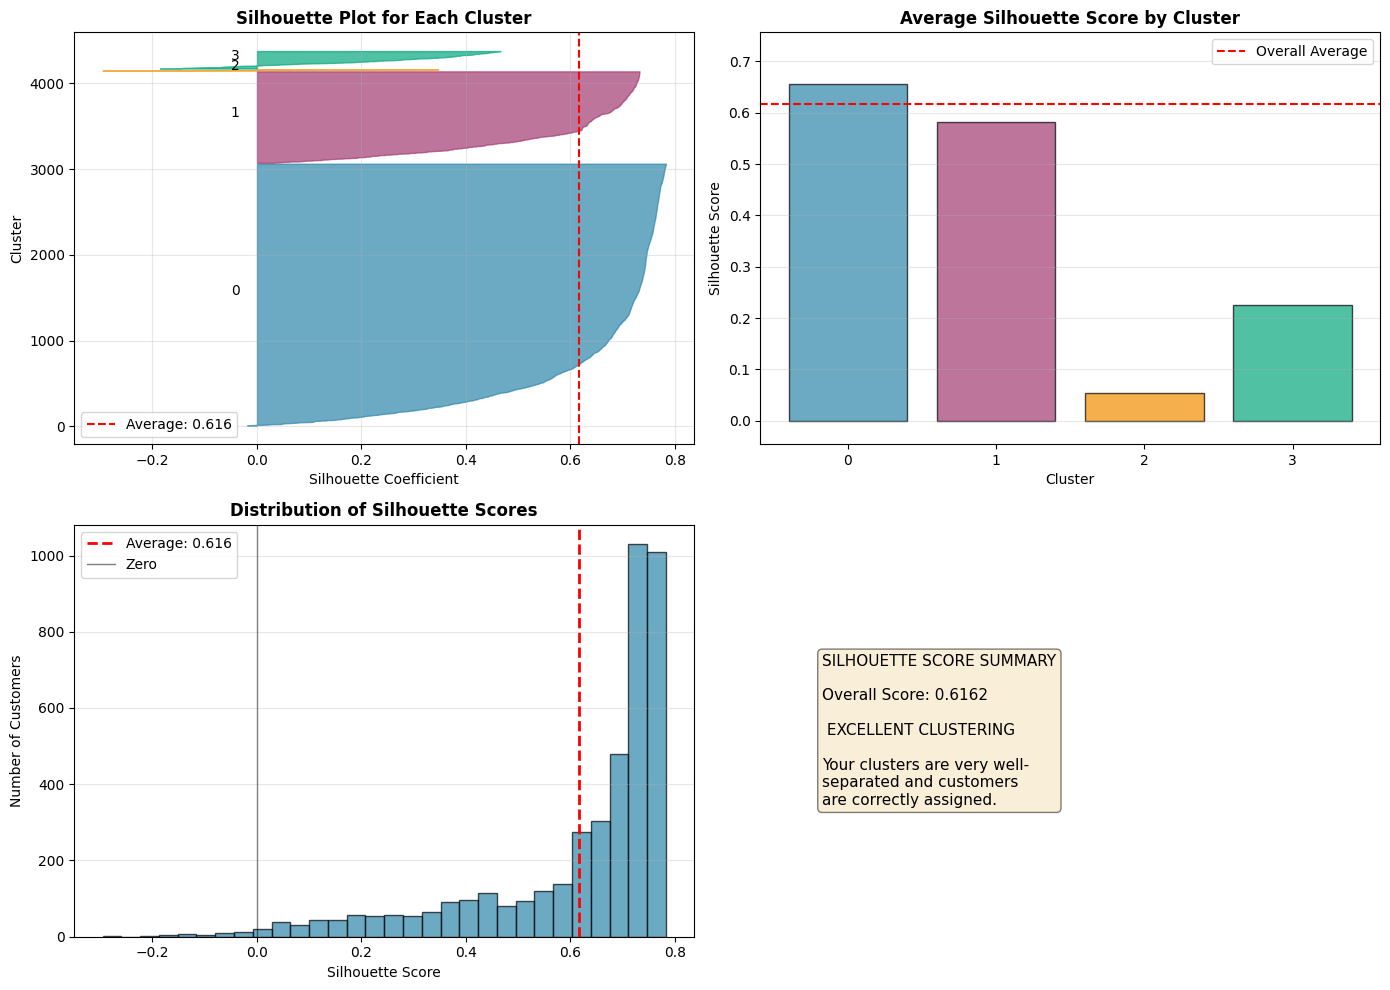


Silhouette visualization complete!


In [34]:
# Visualize Silhouette Scores
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D']

# Plot 1: Silhouette plot
y_lower = 10
for i in sorted(rfm['Cluster'].unique()):
    cluster_silhouette_vals = silhouette_vals[rfm['Cluster'] == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    axes[0, 0].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                             facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    
    axes[0, 0].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

axes[0, 0].axvline(x=silhouette_avg, color='red', linestyle='--', label=f'Average: {silhouette_avg:.3f}')
axes[0, 0].set_title('Silhouette Plot for Each Cluster', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Silhouette Coefficient')
axes[0, 0].set_ylabel('Cluster')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Bar chart of silhouette by cluster
silhouette_by_cluster = []
for cluster in sorted(rfm['Cluster'].unique()):
    cluster_silhouette_vals = silhouette_vals[rfm['Cluster'] == cluster]
    silhouette_by_cluster.append(cluster_silhouette_vals.mean())

axes[0, 1].bar(range(len(silhouette_by_cluster)), silhouette_by_cluster, color=colors[:len(silhouette_by_cluster)], edgecolor='black', alpha=0.7)
axes[0, 1].axhline(y=silhouette_avg, color='red', linestyle='--', label=f'Overall Average')
axes[0, 1].set_title('Average Silhouette Score by Cluster', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_xticks(range(len(silhouette_by_cluster)))
axes[0, 1].set_ylim([min(silhouette_by_cluster) - 0.1, max(silhouette_by_cluster) + 0.1])
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Distribution of silhouette values
axes[1, 0].hist(silhouette_vals, bins=30, color='#2E86AB', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=silhouette_avg, color='red', linestyle='--', linewidth=2, label=f'Average: {silhouette_avg:.3f}')
axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Zero')
axes[1, 0].set_title('Distribution of Silhouette Scores', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Silhouette Score')
axes[1, 0].set_ylabel('Number of Customers')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Summary interpretation
axes[1, 1].axis('off')
summary_text = f'''SILHOUETTE SCORE SUMMARY

Overall Score: {silhouette_avg:.4f}

'''

if silhouette_avg > 0.6:
    summary_text += ' EXCELLENT CLUSTERING\n\nYour clusters are very well-\nseparated and customers\nare correctly assigned.'
elif silhouette_avg > 0.4:
    summary_text += ' GOOD CLUSTERING\n\nYour clusters are reasonably\nwell-separated. Some customers\nmay be on cluster boundaries.'
elif silhouette_avg > 0.2:
    summary_text += ' ACCEPTABLE CLUSTERING\n\nClusters overlap somewhat.\nSome customers may be\nmisassigned.'
else:
    summary_text += ' POOR CLUSTERING\n\nClusters overlap significantly.\nConsider different K value.'

axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print('\nSilhouette visualization complete!')

## Metric 2: Davies-Bouldin Index (Cluster Separation)

In [35]:
# Calculate Davies-Bouldin Index
dbi = davies_bouldin_score(rfm_scaled, rfm['Cluster'])

print(f'\nDAVIES-BOULDIN INDEX: {dbi:.4f}')
print('='*70)

if dbi < 1.5:
    print(f'EXCELLENT! ({dbi:.4f}) - Clusters are very well separated!')
elif dbi < 2.0:
    print(f'GOOD! ({dbi:.4f}) - Clusters are well separated')
elif dbi < 3.0:
    print(f'OKAY ({dbi:.4f}) - Clusters have some overlap')
else:
    print(f'POOR ({dbi:.4f}) - Clusters overlap significantly')

print('\nWhat this means:')
print('→ Lower values = Better separation between clusters')
print('→ Measures average similarity between each cluster and its most similar neighbor')
print('→ Target: < 2.0')


DAVIES-BOULDIN INDEX: 0.7542
EXCELLENT! (0.7542) - Clusters are very well separated!

What this means:
→ Lower values = Better separation between clusters
→ Measures average similarity between each cluster and its most similar neighbor
→ Target: < 2.0


## Metric 3: Inertia (Cluster Tightness)

In [36]:
# Recreate K-Means model to get inertia
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_final.fit(rfm_scaled)
inertia = kmeans_final.inertia_

print(f'\nINERTIA: {inertia:.2f}')
print('='*70)
print('\nWhat this measures:')
print('→ Total distance of all customers to their cluster center')
print('→ Lower = Tighter clusters')
print('→ Useful for comparing different K values')
print(f'\nAverage inertia per customer: {inertia / len(rfm):.4f}')
print('\nWhat this means:')
print('→ On average, each customer is', f'{np.sqrt(inertia / len(rfm)):.4f}', 'units away from their cluster center')
print('→ (Units are normalized, so scale is 0-1)')


INERTIA: 4096.30

What this measures:
→ Total distance of all customers to their cluster center
→ Lower = Tighter clusters
→ Useful for comparing different K values

Average inertia per customer: 0.9443

What this means:
→ On average, each customer is 0.9717 units away from their cluster center
→ (Units are normalized, so scale is 0-1)


## Step 3: Analyze Cluster Profiles (Business Interpretation)

This is THE MOST IMPORTANT evaluation!

In [37]:
print('\nCLUSTER PROFILES - DETAILED ANALYSIS')
print('='*80)

cluster_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary', 'AOV', 'Days_as_Customer', 'Purchase_Rate']].agg([
    'count', 'mean', 'median', 'min', 'max'
])

for cluster in sorted(rfm['Cluster'].unique()):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    
    print(f'\n\nCLUSTER {cluster}:')
    print('-'*80)
    
    # Size
    size = len(cluster_data)
    percent = size / len(rfm) * 100
    print(f'\nSize: {size} customers ({percent:.1f}% of total)')
    
    # Revenue
    total_revenue = cluster_data['Monetary'].sum()
    revenue_percent = total_revenue / rfm['Monetary'].sum() * 100
    print(f'Total Revenue: £{total_revenue:,.2f} ({revenue_percent:.1f}% of total)')
    
    # RFM Statistics
    print(f'\nRecency (days since last purchase):')
    print(f'  Mean: {cluster_data["Recency"].mean():.0f} days')
    print(f'  Median: {cluster_data["Recency"].median():.0f} days')
    print(f'  Range: {cluster_data["Recency"].min():.0f} - {cluster_data["Recency"].max():.0f} days')
    
    print(f'\nFrequency (number of purchases):')
    print(f'  Mean: {cluster_data["Frequency"].mean():.0f} purchases')
    print(f'  Median: {cluster_data["Frequency"].median():.0f} purchases')
    print(f'  Range: {cluster_data["Frequency"].min():.0f} - {cluster_data["Frequency"].max():.0f} purchases')
    
    print(f'\nMonetary (total spending):')
    print(f'  Mean: £{cluster_data["Monetary"].mean():.2f}')
    print(f'  Median: £{cluster_data["Monetary"].median():.2f}')
    print(f'  Range: £{cluster_data["Monetary"].min():.2f} - £{cluster_data["Monetary"].max():.2f}')
    
    # Extra metrics
    print(f'\nOther Metrics:')
    print(f'  Avg Order Value: £{cluster_data["AOV"].mean():.2f}')
    print(f'  Days as Customer: {cluster_data["Days_as_Customer"].mean():.0f} days')
    print(f'  Purchase Rate: {cluster_data["Purchase_Rate"].mean():.3f} purchases/day')


CLUSTER PROFILES - DETAILED ANALYSIS


CLUSTER 0:
--------------------------------------------------------------------------------

Size: 3054 customers (70.4% of total)
Total Revenue: £4,133,971.70 (46.5% of total)

Recency (days since last purchase):
  Mean: 44 days
  Median: 32 days
  Range: 1 - 163 days

Frequency (number of purchases):
  Mean: 4 purchases
  Median: 3 purchases
  Range: 1 - 15 purchases

Monetary (total spending):
  Mean: £1353.63
  Median: £826.27
  Range: £6.20 - £21429.39

Other Metrics:
  Avg Order Value: £375.06
  Days as Customer: 152 days
  Purchase Rate: 0.306 purchases/day


CLUSTER 1:
--------------------------------------------------------------------------------

Size: 1067 customers (24.6% of total)
Total Revenue: £510,931.64 (5.7% of total)

Recency (days since last purchase):
  Mean: 248 days
  Median: 243 days
  Range: 143 - 374 days

Frequency (number of purchases):
  Mean: 2 purchases
  Median: 1 purchases
  Range: 1 - 12 purchases

Monetary (tot

In [38]:
print('\n\n' + '='*80)
print('CLUSTER INTERPRETATION & NAMING')
print('='*80)

# Determine cluster names based on RFM
cluster_names_dict = {}

for cluster in sorted(rfm['Cluster'].unique()):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    
    recency = cluster_data['Recency'].mean()
    frequency = cluster_data['Frequency'].mean()
    monetary = cluster_data['Monetary'].mean()
    
    # Categorize
    recency_cat = 'Recent' if recency < 60 else 'Medium' if recency < 150 else 'Old'
    frequency_cat = 'High' if frequency > 50 else 'Medium' if frequency > 20 else 'Low'
    monetary_cat = 'High' if monetary > 1000 else 'Medium' if monetary > 300 else 'Low'
    
    # Assign names
    if recency_cat == 'Recent' and frequency_cat == 'High' and monetary_cat == 'High':
        name = 'Champions / VIP'
        description = 'Best customers! Recently active, loyal, high spenders'
        action = 'Reward loyalty, exclusive offers, VIP treatment'
    elif recency_cat == 'Old' and frequency_cat == 'Low' and monetary_cat == 'Low':
        name = 'Lost / Dormant'
        description = 'Haven\'t bought in ages, rarely purchased, low spend'
        action = 'Win-back campaign, special discounts, re-engagement'
    elif recency_cat == 'Recent' and frequency_cat == 'Low' and monetary_cat == 'Low':
        name = 'New Customers'
        description = 'Recently acquired, still testing, low spend'
        action = 'Onboarding, education, nurture to increase frequency'
    else:
        name = 'Regulars / Mid-tier'
        description = 'Steady customers, moderate activity and spending'
        action = 'Maintain engagement, cross-sell, upsell opportunities'
    
    cluster_names_dict[cluster] = name
    
    print(f'\n\nCluster {cluster}: {name}')
    print('-'*80)
    print(f'Description: {description}')
    print(f'Size: {len(cluster_data)} customers')
    print(f'Revenue: £{cluster_data["Monetary"].sum():,.2f}')
    print(f'\nCharacteristics:')
    print(f'  • Recency: {recency_cat} ({recency:.0f} days)')
    print(f'  • Frequency: {frequency_cat} ({frequency:.0f} purchases)')
    print(f'  • Monetary: {monetary_cat} (£{monetary:.2f})')
    print(f'\nRecommended Action:')
    print(f'  {action}')



CLUSTER INTERPRETATION & NAMING


Cluster 0: Regulars / Mid-tier
--------------------------------------------------------------------------------
Description: Steady customers, moderate activity and spending
Size: 3054 customers
Revenue: £4,133,971.70

Characteristics:
  • Recency: Recent (44 days)
  • Frequency: Low (4 purchases)
  • Monetary: High (£1353.63)

Recommended Action:
  Maintain engagement, cross-sell, upsell opportunities


Cluster 1: Regulars / Mid-tier
--------------------------------------------------------------------------------
Description: Steady customers, moderate activity and spending
Size: 1067 customers
Revenue: £510,931.64

Characteristics:
  • Recency: Old (248 days)
  • Frequency: Low (2 purchases)
  • Monetary: Medium (£478.85)

Recommended Action:
  Maintain engagement, cross-sell, upsell opportunities


Cluster 2: Champions / VIP
--------------------------------------------------------------------------------
Description: Best customers! Recently activ

## Comparison: All Clusters Side by Side

In [39]:
# Create comparison table
comparison_df = pd.DataFrame()

for cluster in sorted(rfm['Cluster'].unique()):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    
    comparison_df[f'Cluster {cluster}'] = [
        f"{len(cluster_data)} ({len(cluster_data)/len(rfm)*100:.1f}%)",
        f"£{cluster_data['Monetary'].sum():,.0f}",
        f"{cluster_data['Recency'].mean():.0f}",
        f"{cluster_data['Frequency'].mean():.0f}",
        f"£{cluster_data['Monetary'].mean():.2f}",
        f"£{cluster_data['AOV'].mean():.2f}"
    ]

comparison_df.index = ['Size', 'Total Revenue', 'Avg Recency', 'Avg Frequency', 'Avg Spending', 'Avg Order Value']

print('\nCOMPARISON TABLE:')
print('='*100)
print(comparison_df.to_string())


COMPARISON TABLE:
                    Cluster 0     Cluster 1   Cluster 2   Cluster 3
Size             3054 (70.4%)  1067 (24.6%)   13 (0.3%)  204 (4.7%)
Total Revenue      £4,133,972      £510,932  £1,653,443  £2,588,862
Avg Recency                44           248           7          16
Avg Frequency               4             2          83          22
Avg Spending         £1353.63       £478.85  £127187.96   £12690.50
Avg Order Value       £375.06       £313.70    £8569.26    £1079.42


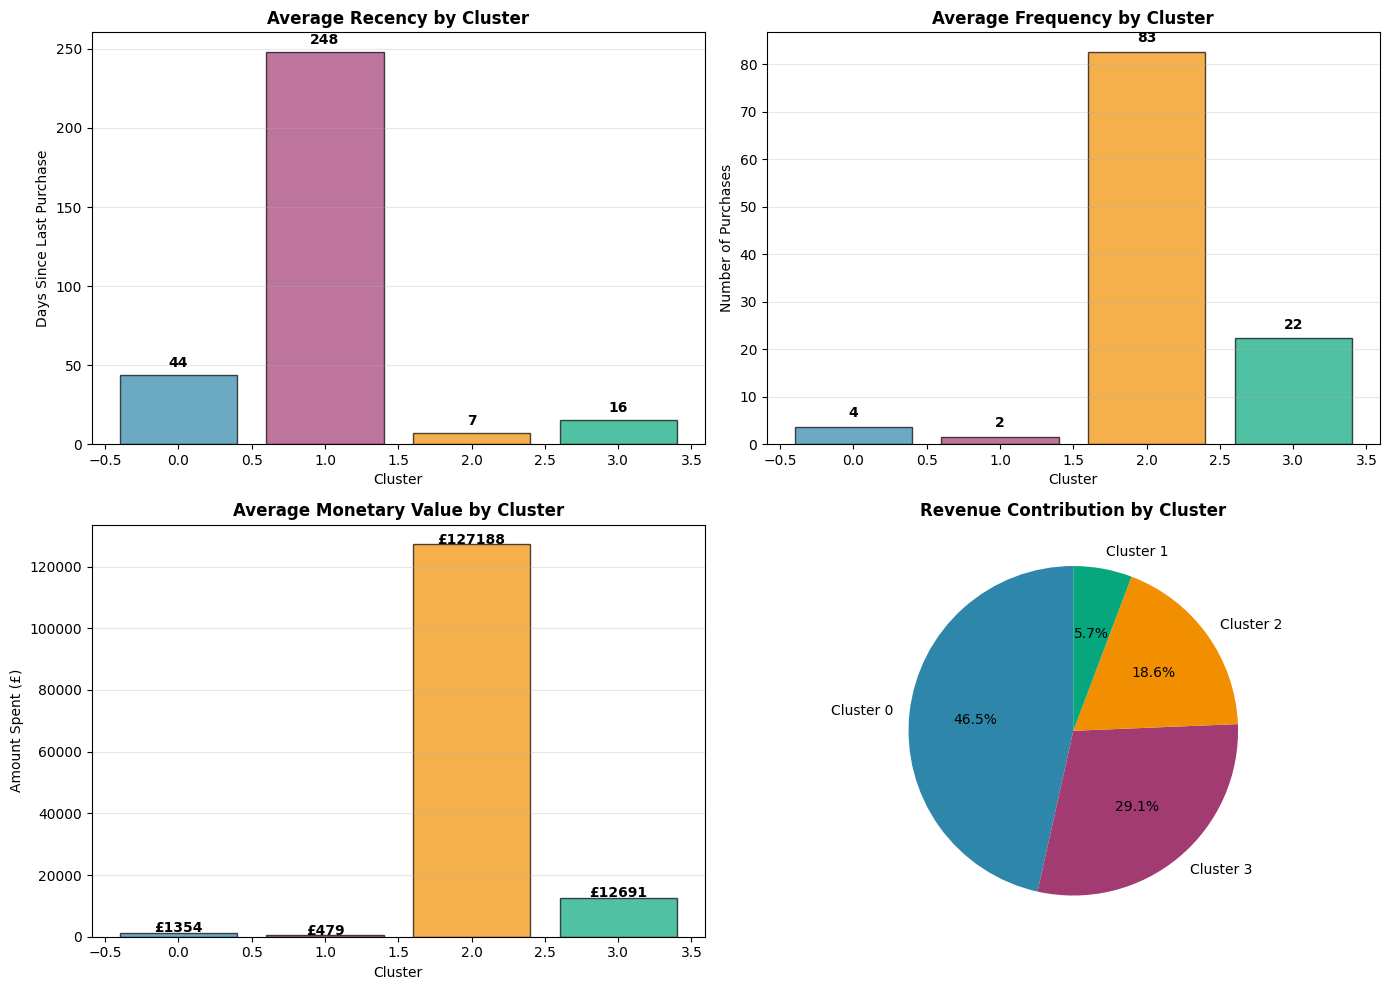

Profile visualizations complete!


In [40]:
# Visualize cluster profiles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D']

cluster_stats = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Plot 1: Recency by cluster
axes[0, 0].bar(cluster_stats.index, cluster_stats['Recency'], color=colors, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Average Recency by Cluster', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Days Since Last Purchase')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cluster_stats['Recency']):
    axes[0, 0].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

# Plot 2: Frequency by cluster
axes[0, 1].bar(cluster_stats.index, cluster_stats['Frequency'], color=colors, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Average Frequency by Cluster', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Number of Purchases')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cluster_stats['Frequency']):
    axes[0, 1].text(i, v + 2, f'{v:.0f}', ha='center', fontweight='bold')

# Plot 3: Monetary by cluster
axes[1, 0].bar(cluster_stats.index, cluster_stats['Monetary'], color=colors, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Average Monetary Value by Cluster', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Amount Spent (£)')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cluster_stats['Monetary']):
    axes[1, 0].text(i, v + 50, f'£{v:.0f}', ha='center', fontweight='bold')

# Plot 4: Revenue contribution
revenue_by_cluster = rfm.groupby('Cluster')['Monetary'].sum().sort_values(ascending=False)
axes[1, 1].pie(revenue_by_cluster, labels=[f'Cluster {c}' for c in revenue_by_cluster.index],
               autopct='%1.1f%%', colors=colors, startangle=90)
axes[1, 1].set_title('Revenue Contribution by Cluster', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('Profile visualizations complete!')

## Final Evaluation Summary

In [41]:
print('\n' + '='*80)
print('FINAL EVALUATION SUMMARY')
print('='*80)

print(f'\nCLUSTERING METRICS:')
print(f'\n  Silhouette Score: {silhouette_avg:.4f}', end='')
if silhouette_avg > 0.6:
    print('===> EXCELLENT')
elif silhouette_avg > 0.4:
    print('===> GOOD')
elif silhouette_avg > 0.2:
    print('===> ACCEPTABLE')
else:
    print('===>NEEDS IMPROVEMENT')

print(f'  Davies-Bouldin Index: {dbi:.4f}', end='')
if dbi < 1.5:
    print('===> EXCELLENT')
elif dbi < 2.0:
    print('===> GOOD')
elif dbi < 3.0:
    print('===> ACCEPTABLE')
else:
    print('===> NEEDS IMPROVEMENT')

print(f'  Inertia: {inertia:.2f} (===>Lower is better)')

print(f'\nBUSINESS INSIGHTS:')
print(f'\n  Total Customers: {len(rfm):,}')
print(f'  Total Revenue: £{rfm["Monetary"].sum():,.2f}')
print(f'  Number of Segments: {rfm["Cluster"].nunique()}')
print(f'\n  Segment Breakdown:')
for cluster in sorted(rfm['Cluster'].unique()):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    size = len(cluster_data)
    revenue = cluster_data['Monetary'].sum()
    revenue_pct = revenue / rfm['Monetary'].sum() * 100
    print(f'    Cluster {cluster}: {size:3d} customers, £{revenue:8,.0f} ({revenue_pct:5.1f}%)')

print(f'\nVERDICT:')
if silhouette_avg > 0.4 and dbi < 2.5:
    print(f'\n  Your clustering is GOOD and ready for business action!')
    print(f'  \n  Next steps:')
    print(f'  1. Create a business dashboard to visualize segments')
    print(f'  2. Develop targeted strategies for each segment')
    print(f'  3. Monitor segment changes over time')
else:
    print(f'\n  Your clustering could be improved.')
    print(f'  Consider: Different K value, feature scaling, or feature selection')

print('\n' + '='*80)


FINAL EVALUATION SUMMARY

CLUSTERING METRICS:

  Silhouette Score: 0.6162===> EXCELLENT
  Davies-Bouldin Index: 0.7542===> EXCELLENT
  Inertia: 4096.30 (===>Lower is better)

BUSINESS INSIGHTS:

  Total Customers: 4,338
  Total Revenue: £8,887,208.89
  Number of Segments: 4

  Segment Breakdown:
    Cluster 0: 3054 customers, £4,133,972 ( 46.5%)
    Cluster 1: 1067 customers, £ 510,932 (  5.7%)
    Cluster 2:  13 customers, £1,653,443 ( 18.6%)
    Cluster 3: 204 customers, £2,588,862 ( 29.1%)

VERDICT:

  Your clustering is GOOD and ready for business action!
  
  Next steps:
  1. Create a business dashboard to visualize segments
  2. Develop targeted strategies for each segment
  3. Monitor segment changes over time



## Save Evaluation Results

In [42]:
# Save evaluation metrics
evaluation_results = {
    'Silhouette Score': silhouette_avg,
    'Davies-Bouldin Index': dbi,
    'Inertia': inertia,
    'Number of Clusters': 4,
    'Total Customers': len(rfm),
    'Total Revenue': rfm['Monetary'].sum()
}

# Save as CSV for reference
eval_df = pd.DataFrame([evaluation_results])
eval_df.to_csv('model_evaluation.csv', index=False)

print('Evaluation metrics saved to model_evaluation.csv')
print('Segmented customers saved in customer_segments.csv')

Evaluation metrics saved to model_evaluation.csv
Segmented customers saved in customer_segments.csv
